### Introduction

This notebook serves as a short tutorial on how to use the axion emulator to predict the boost to the non-linear matter power spectrum in cosmologies containing a mixture of cold dark matter (CDM) and ultralight axions (ULAs). Below I show a few practical examples illustrating the emulator's functionality. The examples cover the basic steps of loading the trained model, preparing input parameters, and generating predictions. 

The first step is setting up the right environment. Here I recommend setting up a virtual environment and installing the required modules. 
```bash
python -m venv /path/to/venv
source /path/to/env/bin/activate
```
I have compiled a list of python packages that I use when running the model. If you wish to install these, you can do so with
```bash
python -m pip install -r requirements.txt
```


Once the environment is set up, the model can be set up using e.g.
```python
from src.axionemulator import axionemulator
model = axionemulator(version=2)
```

Within the `emulators/lightning_logs` directory, you can find various version of the model that are trained with different hyperparameters (if you are curious, check `version_i/config.yaml`). I found that `version=2` gives the best results. 

In [96]:
### Import basic packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from matplotlib import gridspec
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams.update({'font.size': 14})
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
params = {'xtick.top': True, 'ytick.right': True, 'xtick.direction': 'in', 'ytick.direction': 'in'}
plt.rcParams.update(params)

from matplotlib.legend_handler import HandlerTuple

# Import the emulator
from src.axionemulator import axionemulator
model = axionemulator(version=3)                # Load the emulator & weights

Lightning automatically upgraded your loaded checkpoint from v1.5.10 to v2.6.6. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint emulators/lightning_logs/version_3/checkpoints/epoch=169-step=250239.ckpt`


### Running the emulator

I have set up the emulator to handle normalization and arrays, such that if you want to make a prediction over a range of $k$-values, you need only supply it as an array. This also goes if you want to, for example, vary the axion fraction $f_{\rm ax}$ and keep the wavenumer constant. The way the model is currently set up, it should also be able to handle combinations of these, e.g. if you supply a $k$-array and a $f_{\rm ax}$-array, it should give you the prediction for $[k_i, f_{i, \rm ax}]$ in 1D. (so you won't get a grid of every possible combination, but rather something like `zip(k, f)`)

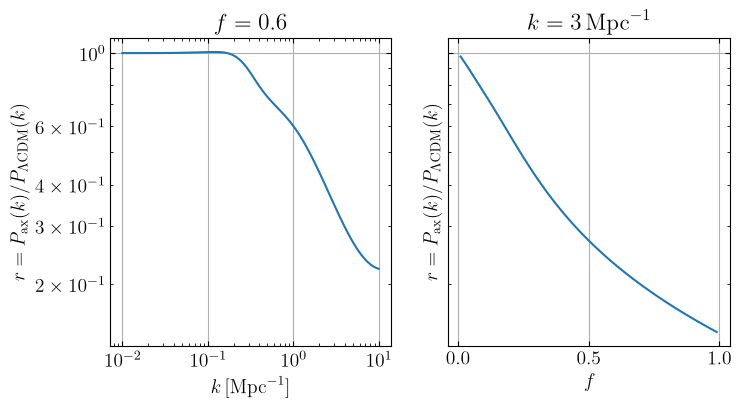

In [97]:
### Simple example of how to use the emulator with one varying parameter
Omega_cdm = 0.2637
A_s = 2.1e-9
f = 0.6
m = 1e-25
z = 0.0
k = np.logspace(np.log10(0.01), np.log10(10), num=100)


fig, ax = plt.subplots(figsize=(8, 4), ncols=2, sharey=True)

# Here we vary k and keep f fixed
r = model(Omega_cdm=Omega_cdm, A_s=A_s, f=f, m=m, z=z, k=k)


ax[0].loglog(k, r)
ax[0].set_ylabel(r"$r = P_{\rm ax}(k) / P_{\rm \Lambda CDM}(k)$")
ax[0].set_xlabel(r"$k \, [{\rm Mpc}^{-1}]$")
ax[0].set_title(r"$f = 0.6$")


# Here we vary f and keep k fixed
k = 8
f = np.linspace(0.01, 0.99, num=100)
r = model(Omega_cdm=Omega_cdm, A_s=A_s, f=f, m=m, z=z, k=k)

ax[1].plot(f, r)
ax[1].set_ylabel(r"$r = P_{\rm ax}(k) / P_{\rm \Lambda CDM}(k)$")
ax[1].set_xlabel(r"$f$")
ax[1].set_title(r"$k = 3 \, {\rm Mpc}^{-1}$")


[axi.grid() for axi in ax];

### Working with `predict`

You can "hack" the emulator to generate a prediction for a more complicated input. As an example, below I create a prediction for a grid of $k$- and $f_{\rm ax}$-values. To do this, you may call `model.predictor(input)`, where the input is some $N$-dimentional array. The only requirements from the model is that the last dimension indexes the parameter (e.g. has 6 elements), and that the parameters are properly normalized. Since our model is trained using `log10` of $A_s$, $f_{\rm ax}$, $m_{\rm ax}$, and $k$, these need to be normalized as such. The values must also come in this order: `[Om_cdm, log10(A_s), log10(f), log10(m), z, log10(k)]`.

(100, 25, 6)


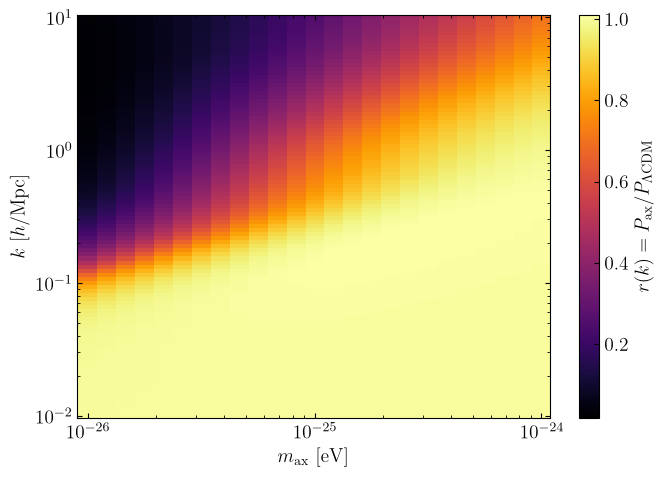

In [98]:
### If you want a more complicated call, here is an example for predicting over a range of k and m values.
Omega_cdm = 0.2637
A_s = 2.1e-9
f = 0.5
m = np.logspace(np.log10(1e-26), np.log10(1e-24), num=25)
z = 0.0
k = np.logspace(np.log10(0.01), np.log10(10), num=100)

# Create grid
K, M = np.meshgrid(k, m, indexing="ij")

# Create input array with shape (100, 25, 6)
inputs = np.stack([
    np.full_like(K, Omega_cdm),
    np.full_like(K, np.log10(A_s)),
    np.full_like(K, np.log10(f)),
    np.log10(M),
    np.full_like(K, z),
    np.log10(K),
], axis=-1)

print(inputs.shape)  # (100, 25, 6)

# Predict
P = model.predictor(inputs)[:,:,0]  # (100, 25, 1) -> (100, 25)


fig, ax = plt.subplots(figsize=(7, 5))

im = ax.pcolormesh(
    m, k, P,
    shading="auto",
    cmap="inferno"
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$m_{\rm ax}\ [\mathrm{eV}]$")
ax.set_ylabel(r"$k\ [h/\mathrm{Mpc}]$")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$r(k) = P_{\rm ax}/P_{\rm \Lambda CDM}$")

plt.tight_layout()
plt.show()

### Application 

Below, I insert a script that compares the model's prediction to `CAMB`, `axionHMcode`, and `HMcode`. If you have set up everything correctly, you should get the same results as me here. (...)

If you wish to use the emulator to make prediction for the non-linear matter power spectrum with mixed axions and CDM, I suggest combining our emulator with a $\Lambda$-CDM emulator, such as the `EuclidEmulator`. 

In [99]:
Omega_b = 0.049
OmegaMnu = 0.0
h = 0.6766

Omega_cdm = 0.2637
A_s = 2.1e-9
n_s = 0.966
redshift = 0.0

data_camb_LCDM = np.loadtxt("data/axioncamb_1e-23_0.300_LCDM_matterpower_z0.0.dat")
data_axionHM_LCDM = np.loadtxt("data/LCDM.txt")
data_HM_LCDM = np.loadtxt("data/HM_LCDM.dat")

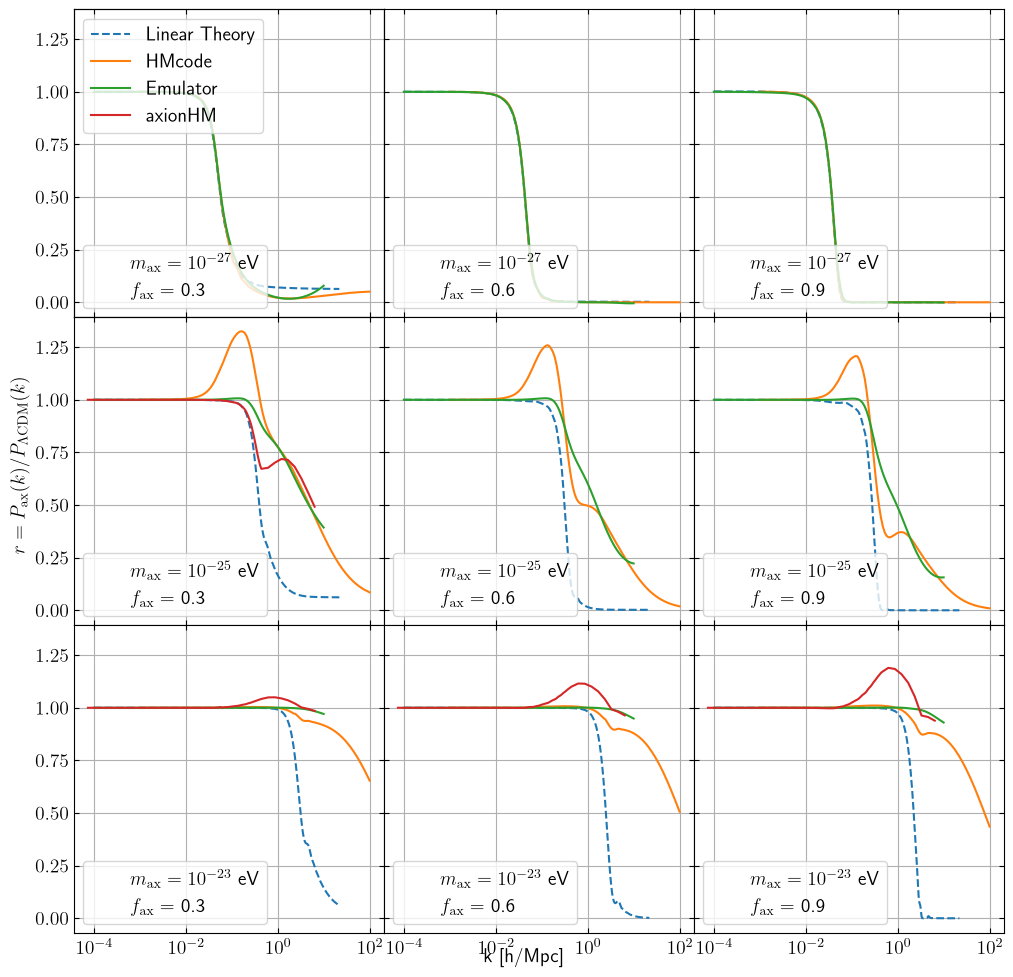

In [100]:
f = [0.3, 0.6, 0.9]
m = [1e-27, 1e-25, 1e-23]

fig, ax = plt.subplots(figsize=(12,12), sharex=True, sharey=True,ncols=3, nrows=3)

plot = True

for i, mi in enumerate(m):
    for j, fj in enumerate(f):
        label="%.e_%.3f"%(mi,fj)

        data_camb = np.loadtxt("data/axioncamb_"+label+"_matterpower_z0.0.dat")
        data_camb_LCDM = np.loadtxt("data/axioncamb_"+label+"_LCDM_matterpower_z0.0.dat")
        try:
            plot = True
            data_axionHM = np.loadtxt("data/axion_"+label+".txt")
        except:
            plot = False
            pass
        data_HM = np.loadtxt("data/HM_"+label+".dat")

        #k = data_axionHM[:,0]
        k = np.logspace(np.log10(data_camb[0,0]), np.log10(5), 126)
        k = np.logspace(-4, np.log10(5), 126)

        if i == 0 and j == 0:
            ax[i,j].plot(data_camb[:,0], data_camb[:,1]/data_camb_LCDM[:len(data_camb[:,1]),1], ls="--", label="Linear Theory")
            ax[i,j].plot(data_HM[:,0], data_HM[:,16]/data_HM_LCDM[:,16], label="HMcode")
        else: 
            ax[i,j].plot(data_camb[:,0], data_camb[:,1]/data_camb_LCDM[:len(data_camb[:,1]),1], ls="--")
            ax[i,j].plot(data_HM[:,0], data_HM[:,16]/data_HM_LCDM[:,16])

        k = np.logspace(np.log10(data_camb[0,0]), np.log10(10), 126)
        if i == 0 and j == 0:
            ax[i,j].plot(k, model(Omega_cdm, A_s, fj, mi, redshift, k), label="Emulator")
        else: 
            ax[i,j].plot(k, model(Omega_cdm, A_s, fj, mi, redshift, k)) 

        
        if plot:
            if i == 0 and j == 0:
                ax[i,j].plot(data_axionHM[:,0], data_axionHM[:,1]/data_axionHM[:,2], label="axionHM")
            else:
                ax[i,j].plot(data_axionHM[:,0], data_axionHM[:,1]/data_axionHM[:,2])
        else:
            if i == 0 and j == 0:
                ax[i,j].plot([], [], label="axionHM")
    
        mantissa, exponent = f"{mi:.1e}".split("e")
        exponent = int(exponent)

        if i == 0 and j == 0:
            ax2 = ax[i,j].twinx()
            ax2.plot([], [], label=r"$m_{\rm ax} = 10^{%d}$ eV"%(exponent), ls='None')
            ax2.plot([], [], label=r"$f_{\rm ax} =$ %.1f"%(fj), ls='None')
            legend = ax2.legend(loc=3, handletextpad=0)
            ax2.get_yaxis().set_visible(False)
            ax[i,j].legend(loc=2)
        else:
            ax[i,j].plot([], [], label=r"$m_{\rm ax} = 10^{%d}$ eV"%(exponent), ls='None')
            ax[i,j].plot([], [], label=r"$f_{\rm ax} =$ %.1f"%(fj), ls='None')

            legend = ax[i,j].legend(loc=3, handler_map={tuple: HandlerTuple(ndivide=None)}, handletextpad=0)

        for handle in legend.legend_handles:
            handle.set_visible(False)

        ax[i,j].grid()
        ax[i,j].set_xscale("log")
        #ax[i,j].set_yscale("log")

        #ax[i,j].legend()
#ax[0,0].legend()

#ax = fig.add_axes([0,0,1,1])

#ax.set_xlabel("k [h/Mpc]")
#fig.supylabel(r"P(k) [(Mpc/h)$^3$]")
fig.text(0.5, 0.09, 'k [h/Mpc]', va='center', ha='center')
fig.text(0.08, 0.5, r"$r = P_{\rm ax}(k)/P_{\Lambda \rm CDM}(k)$", va='center', ha='center', rotation='vertical')

plt.subplots_adjust(hspace=0.0, wspace=0.0)
#plt.savefig("figures/comparison_high_f_ax.pdf", bbox_inches="tight")
plt.show()

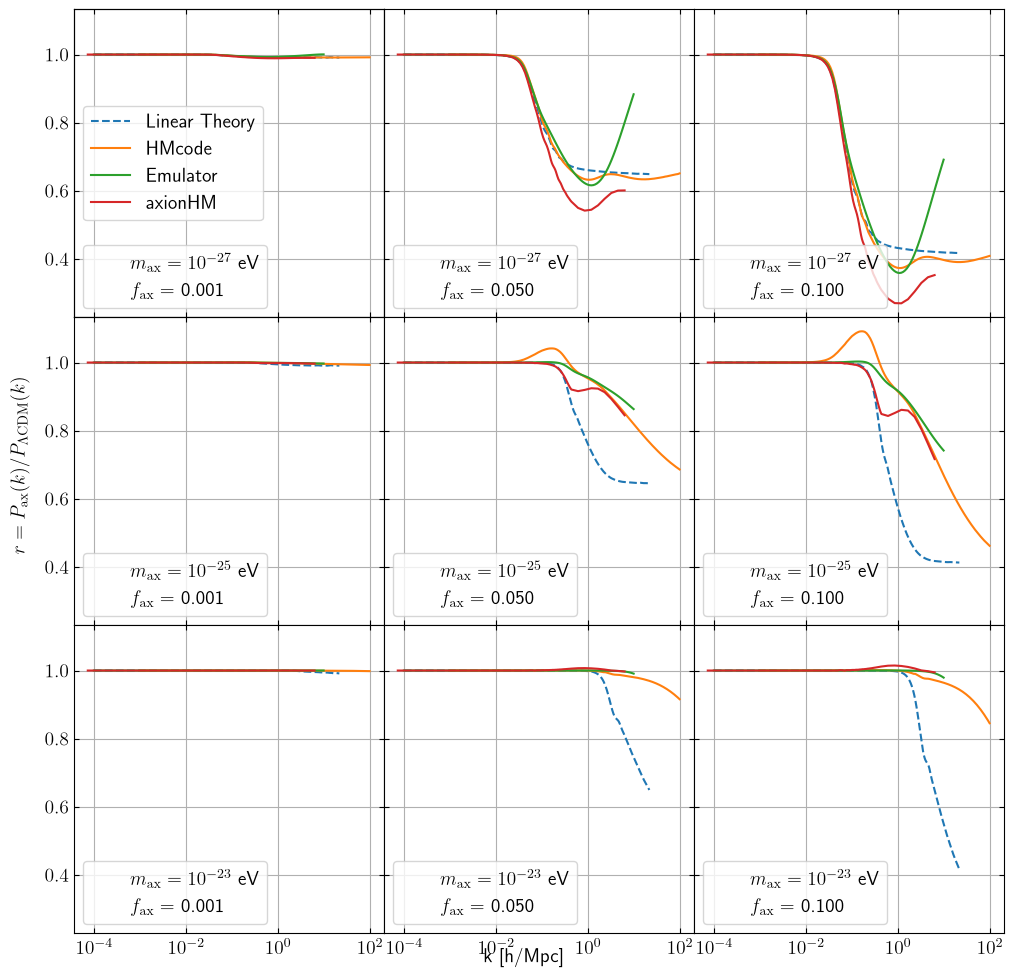

In [101]:
f = [0.001, 0.05, 0.1]
m = [1e-27, 1e-25, 1e-23]

fig, ax = plt.subplots(figsize=(12,12), sharex=True, sharey=True,ncols=3, nrows=3)

for i, mi in enumerate(m):
    for j, fj in enumerate(f):
        label="%.e_%.3f"%(mi,fj)

        data_camb = np.loadtxt("data/axioncamb_"+label+"_matterpower_z0.0.dat")
        data_camb_LCDM = np.loadtxt("data/axioncamb_"+label+"_LCDM_matterpower_z0.0.dat")
        data_axionHM = np.loadtxt("data/axion_"+label+".txt")
        data_HM = np.loadtxt("data/HM_"+label+".dat")

        
        if i == 0 and j == 0:
            ax[i,j].plot(data_camb[:,0], data_camb[:,1]/data_camb_LCDM[:len(data_camb[:,1]),1], ls="--", label="Linear Theory")
            ax[i,j].plot(data_HM[:,0], data_HM[:,16]/data_HM_LCDM[:,16], label="HMcode")
        else:
            ax[i,j].plot(data_camb[:,0], data_camb[:,1]/data_camb_LCDM[:len(data_camb[:,1]),1], ls="--")
            ax[i,j].plot(data_HM[:,0], data_HM[:,16]/data_HM_LCDM[:,16])


        k = np.logspace(-4, np.log10(10), 126)
        if i == 0 and j == 0:
            ax[i,j].plot(k, model(Omega_cdm, A_s, fj, mi, redshift, k), label="Emulator")
            ax[i,j].plot(data_axionHM[:,0], data_axionHM[:,1]/data_axionHM[:,2], label="axionHM")

        else: 
            ax[i,j].plot(k, model(Omega_cdm, A_s, fj, mi, redshift, k))
            ax[i,j].plot(data_axionHM[:,0], data_axionHM[:,1]/data_axionHM[:,2])

        ax[i,j].grid()
        ax[i,j].set_xscale("log")
        #ax[i,j].set_yscale("log")

        mantissa, exponent = f"{mi:.1e}".split("e")
        exponent = int(exponent)

        if i == 0 and j == 0:
            ax2 = ax[i,j].twinx()
            ax2.plot([], [], label=r"$m_{\rm ax} = 10^{%d}$ eV"%(exponent), ls='None')
            ax2.plot([], [], label=r"$f_{\rm ax} =$ %.3f"%(fj), ls='None')
            legend = ax2.legend(loc=3, handletextpad=0)
            ax2.get_yaxis().set_visible(False)
            ax[i,j].legend(loc="center left")
        else:
            ax[i,j].plot([], [], label=r"$m_{\rm ax} = 10^{%d}$ eV"%(exponent), ls='None')
            ax[i,j].plot([], [], label=r"$f_{\rm ax} =$ %.3f"%(fj), ls='None')

            legend = ax[i,j].legend(loc=3, handler_map={tuple: HandlerTuple(ndivide=None)}, handletextpad=0)

        for handle in legend.legend_handles:
            handle.set_visible(False)

fig.text(0.5, 0.09, 'k [h/Mpc]', va='center', ha='center')
fig.text(0.08, 0.5, r"$r = P_{\rm ax}(k)/P_{\Lambda \rm CDM}(k)$", va='center', ha='center', rotation='vertical')

plt.subplots_adjust(hspace=0.0, wspace=0.0)
#plt.savefig("figures/comparison_low_f_ax.pdf", bbox_inches="tight")
plt.show()